# Notebook Objectives

In this notebooks, we'll go through the main behavioral analysis results.

Results include:
* ?
* ?

---
# Setup


In [ ]:
##% title Imports
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import os
import pandas as pd

from neural_value_helpers import create_r_style_plot
import popy.config as cfg
from popy.config import PROJECT_PATH_LOCAL as PATH
from popy.config import COLORS as COLORS

PATH = cfg.PROJECT_PATH_LOCAL


In [ ]:
##% Plotting Functions

# fontsize = 8
plt.rcParams.update({'font.size': 8})


def print_stats(stats_df):
    # print number of sessions per monkey, subregion, and hypothesis
    stats_summary = stats_df.groupby(['monkey', 'subregion', 'hypothesis']).size().reset_index(name='count')
    stats_summary = stats_summary.sort_values(by=['monkey', 'subregion', 'hypothesis'])

    # print in user-friendly format
    for (monkey, subregion), group in stats_summary.groupby(['monkey', 'subregion']):
        print(f"{monkey} - {subregion}:")
        n_sessions = len(stats_df[(stats_df['monkey'] == monkey) & (stats_df['subregion'] == subregion)])
        for _, row in group.iterrows():
            print(f"  {row['hypothesis']}: {row['count']} sessions ({row['count'] / n_sessions * 100:.1f}%)")
        print()  # Add a newline for better readability

    # now plot donut charts for each monkey and sessions

    fig, axs = plt.subplots(1, 3, figsize=(5, 2))
    plt.rcParams.update({'font.size': 8})

    subregions = stats_summary['subregion'].unique()

    for s, subregion in enumerate(subregions):
        group = stats_summary[stats_summary['subregion'] == subregion]
        # sum count per monkey
        group = group.groupby('hypothesis').sum().reset_index()

        # order hypotheses as ['Foraging', 'RL simple', 'RL counterfactual', 'PROBLEM', 'none']
        ordered_hypotheses = ['Foraging', 'RL simple', 'RL counterfactual', 'PROBLEM', 'none']
        group = group.copy()  # Create a copy to avoid SettingWithCopyWarning
        group['hypothesis'] = pd.Categorical(group['hypothesis'], categories=ordered_hypotheses, ordered=True)
        group = group.sort_values('hypothesis')

        ax = axs[s]

        if not group.empty:
            # Get colors for each hypothesis
            colors = [COLORS[hypothesis] for hypothesis in group['hypothesis']]
            
            # Create donut chart with better percentage positioning
            wedges, texts, autotexts = ax.pie(group['count'], 
                                            labels=None,  # Remove labels from chart
                                            colors=colors,
                                            autopct='%1.1f%%',
                                            startangle=90,
                                            counterclock=False,
                                            pctdistance=1,  # Position percentages closer to edge
                                            wedgeprops=dict(alpha=.6, width=0.5))  # This creates the donut hole

            # Improve percentage text formatting
            for autotext in autotexts:
                autotext.set_color('black')
                autotext.set_fontsize(7)
                #autotext.set_weight('bold')
                autotext.set_bbox(dict(boxstyle="round,pad=0.1", facecolor='white', alpha=0.8, edgecolor='none'))

            # Add center circle for better donut appearance
            centre_circle = plt.Circle((0,0), 0.50, fc='white', edgecolor=COLORS[subregion], linewidth=2)
            ax.add_artist(centre_circle)
            # Add circle around (edge)
            centre_circle = plt.Circle((0,0), 1, fc='none', edgecolor=COLORS[subregion], linewidth=2)
            ax.add_artist(centre_circle)

            # Add title in the center
            ax.text(0, 0, f'{subregion}', ha='center', va='center', 
                    fontsize=8, weight='bold', color=COLORS[subregion])

            ax.set_title(f'KA & PO, n={group["count"].sum()}', fontsize=8, pad=10)
            
        else:
            # Hide subplot if no data
            ax.set_visible(False)
    
    # Create legend using all possible hypotheses
    ordered_hypotheses = ['Foraging', 'RL simple', 'RL counterfactual', 'PROBLEM', 'none']
    legend_colors = [COLORS[hypothesis] for hypothesis in ordered_hypotheses]
    legend_handles = [plt.Rectangle((0,0),1,1, facecolor=color) for color in legend_colors]
    
    # Add legend to the figure
    fig.legend(legend_handles, ordered_hypotheses, loc='center left', bbox_to_anchor=(1, 0.5))
    #plt.tight_layout()  # Re-enabled tight_layout for better spacing
    return fig, axs

def plot_session_wise(results_df_mean, monkeys='two'):
    # Create the figure
    # Create the plots

    subregions = results_df_mean['subregion'].unique()
    n_subregions = len(subregions)
    
    if monkeys == 'both':
        # 1x3 grid (or 1xN for N subregions)
        n_rows, n_cols = 1, n_subregions
        fig = plt.figure(figsize=(3 * n_cols, 2))
        
        # Create main grid
        gs_main = gridspec.GridSpec(n_rows, n_cols, figure=fig)
        
        axs = []
        
        for s, subregion in enumerate(subregions):
            group = results_df_mean[results_df_mean['subregion'] == subregion]
            
            # Create subdivided grid for this subplot
            gs_sub = gridspec.GridSpecFromSubplotSpec(1, 2, gs_main[0, s], 
                                                     wspace=0.1, hspace=0.1)
            
            # Create the two sub-axes
            ax1 = fig.add_subplot(gs_sub[0, 0])
            ax2 = fig.add_subplot(gs_sub[0, 1], sharey=ax1)
            
            # Within target plot
            create_r_style_plot(ax1, 
                            group.loc[group['type'] == 'within'], 
                            'feedback', 'dV_neural', 'Within target')
            
            # Alter target plot  
            create_r_style_plot(ax2, 
                            group.loc[group['type'] == 'alter'], 
                            'feedback', 'dV_neural', 'Alter target')
            
            # remove y axis, ticks and labels from 2nd plot
            ax2.yaxis.set_visible(False)
            # Add title for this subregion
            ax1.set_title(f'{subregion}')
            ax2.set_title(f'{subregion}')
            axs.append([ax1, ax2])
    
    else:
        # 2x3 grid (or 2xN for N subregions)
        monkeys_list = results_df_mean['monkey'].unique()
        n_monkeys = len(monkeys_list)
        n_rows, n_cols = n_monkeys, n_subregions
        
        fig = plt.figure(figsize=(5 * n_cols, 3 * n_rows))
        
        # Create main grid
        gs_main = gridspec.GridSpec(n_rows, n_cols, figure=fig)
        
        axs = []
        
        for m, monkey in enumerate(monkeys_list):
            row_axs = []
            for s, subregion in enumerate(subregions):
                group = results_df_mean[(results_df_mean['monkey'] == monkey) & 
                                      (results_df_mean['subregion'] == subregion)]
                
                # Create subdivided grid for this subplot
                gs_sub = gridspec.GridSpecFromSubplotSpec(1, 2, gs_main[m, s], 
                                                         wspace=0.1, hspace=0.1)
                
                # Create the two sub-axes
                ax1 = fig.add_subplot(gs_sub[0, 0])
                ax2 = fig.add_subplot(gs_sub[0, 1], sharey=ax1)
                
                # Within target plot
                create_r_style_plot(ax1, 
                                group.loc[group['type'] == 'within'], 
                                'feedback', 'dV_neural', 'Within target')
                
                # Alter target plot
                create_r_style_plot(ax2, 
                                group.loc[group['type'] == 'alter'], 
                                'feedback', 'dV_neural', 'Alter target')
                
                # Add title for this subplot
                #gs_sub.suptitle(f'{monkey} - {subregion}', fontsize=12, y=0.98)
                
                row_axs.append([ax1, ax2])
            axs.append(row_axs)

    return fig, axs 


In [3]:
def get_data():
    path = os.path.join(cfg.PROJECT_PATH_LOCAL, 'notebooks', 'population_decoding', 'results', 'behav_neural_value_across_target', 'behav.pkl')

    results_df = pd.read_pickle(path)
    # sort by monkey session trial_id target type
    results_df = results_df.sort_values(by=['monkey', 'session', 'subregion', 'trial_id'])
    results_df = results_df.dropna()
    return results_df

def merge_alter_values(results_df):
    """Merge 'alter' type rows by averaging their values for each trial, so that we only have one."""
    # for each (monkey, session, subregion, trial_id), replace the two 'type'=='alter' rows with one that has these attributes, and averages everything else

    results_df_within = results_df[results_df['type'] == 'within']
    results_df_alter = results_df[results_df['type'] == 'alter']

    results_df_alter_means = []
    for (monkey, session, subregion, trial_id), group in results_df_alter.groupby(['monkey', 'session', 'subregion', 'trial_id']):
        mean_row = {}
        mean_row['monkey'] = monkey
        mean_row['session'] = session
        mean_row['subregion'] = subregion
        mean_row['trial_id'] = trial_id
        mean_row['type'] = 'alter'
        mean_row['feedback'] = group['feedback'].values[0]  # or .mean() if you want the average
        mean_row['dV_neural'] = group['dV_neural'].mean()

        results_df_alter_means.append(mean_row)
    results_df_alter_means = pd.DataFrame(results_df_alter_means)

    # Combine the two dataframes
    results_df_combined = pd.concat([results_df_within[results_df_alter_means.columns.tolist()], results_df_alter_means], ignore_index=True)

    # feedback is int

    results_df = results_df_combined
    results_df = results_df.sort_values(by=['monkey', 'session', 'subregion', 'trial_id'])

    # reset index
    results_df = results_df.reset_index(drop=True)

    return results_df

def extract_hypothesis(res):
    stats_df = []
    for (monkey, session, subregion), group in res.groupby(['monkey', 'session', 'subregion']):
        dVs_pos_same = group[(group['feedback'] == 1) & (group['type'] == 'within')]['dV_neural'].values
        dVs_neg_same = group[(group['feedback'] == 0) & (group['type'] == 'within')]['dV_neural'].values
        U_same, p_value_same = stats.mannwhitneyu(dVs_pos_same, dVs_neg_same, alternative='two-sided')

        dVs_pos_alter = group[(group['feedback'] == 1) & (group['type'] == 'alter')]['dV_neural'].values
        dVs_neg_alter = group[(group['feedback'] == 0) & (group['type'] == 'alter')]['dV_neural'].values
        U_alter, p_value_alter = stats.mannwhitneyu(dVs_pos_alter, dVs_neg_alter, alternative='two-sided')

        stats_df.append({
            'monkey': monkey,
            'session': session,
            'subregion': subregion,
            #'hypothesis': hypothese,
            'p_value_same': p_value_same,
            'U_same': U_same,
            'p_value_alter': p_value_alter,
            'U_alter': U_alter,
        })
    # Convert stats to DataFrame
    stats_df = pd.DataFrame(stats_df)

    # FDR correction for p-values per monkey and subregion
    #stats_df = add_corrected_pvals(stats_df)

    # get hypothesis based on p-values
    for i, row in stats_df.iterrows():
        if row['p_value_same'] < 0.05:
            if row['p_value_alter'] < 0.05:
                if row['U_alter'] > 0:
                    hypothese = 'Foraging'
                else:
                    hypothese = 'RL counterfactual'
            else:
                hypothese = 'RL simple'
        else:
            if row['p_value_alter'] < 0.05:
                hypothese = 'none'  # But actually PROBLEM
            else:
                hypothese = 'none'

        stats_df.at[i, 'hypothesis'] = hypothese

    return stats_df

def add_corrected_pvals(cpd_all):
    from statsmodels.stats.multitest import multipletests

    # Get p-value columns
    pval_cols = [col for col in cpd_all.columns if col.startswith('p_value') and not col.endswith('corrected')]

    # Create new columns for corrected p-values
    for col in pval_cols:
        cpd_all[f'{col}_corrected'] = np.nan

    # Apply correction within each group (monkey × subregion)
    for monkey in cpd_all.monkey.unique():
        for subregion in cpd_all.subregion.unique():
            # Get mask for this group
            group_mask = (cpd_all.monkey == monkey) & (cpd_all.subregion == subregion)
            
            # Extract p-values for this group
            group_pvals = cpd_all.loc[group_mask, pval_cols].values
            
            # Apply correction within this group
            rejected, pvals_corrected, _, _ = multipletests(
                group_pvals.flatten(), method='fdr_bh'
            )
            
            # Reshape back to original shape
            pvals_corrected = pvals_corrected.reshape(group_pvals.shape)
            
            # Write back corrected p-values
            for i, col in enumerate(pval_cols):
                cpd_all.loc[group_mask, f'{col}_corrected'] = pvals_corrected[:, i]

    ''' # Now use the corrected p-values
    pval_cols_corrected = [f'{col}_corrected' for col in pval_cols]'''

    return cpd_all


---
# Get data

In [4]:
# Get data
res = get_data()
res = merge_alter_values(res)

# normalize dV_neural within each monkey, session, subregion
res[f'dV_neural'] = res.groupby(['monkey', 'session', 'subregion'])[f'dV_neural'].transform(lambda x: (x - x.mean()) / x.std())
res

,monkey,session,subregion,trial_id,type,feedback,dV_neural
0,ka,010720,MCC,8,within,1,-0.147941
1,ka,010720,MCC,8,alter,1,-0.440085
2,ka,010720,MCC,9,within,1,0.554886
3,ka,010720,MCC,9,alter,1,0.351978
4,ka,010720,MCC,10,within,1,-0.625316
...,...,...,...,...,...,...,...
115373,po,310822,dLPFC,419,alter,0,-2.447534
115374,po,310822,dLPFC,420,within,1,1.042724
115375,po,310822,dLPFC,420,alter,1,0.435004
115376,po,310822,dLPFC,421,within,1,-0.714193


# See results

## Example session


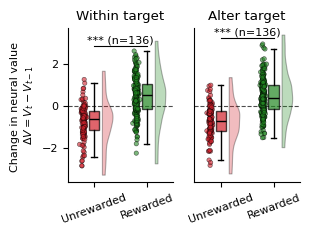

In [22]:
results_df_temp = res[(res['session'] == '210322') & (res['subregion'] == 'MCC')]

# Create the figure
fig, axs = plt.subplots(1, 2, figsize=(3, 2), sharey=True)

# Create the plots
palette = {'0': 'tab:red', '1': 'tab:green'}

# Within target plot
create_r_style_plot(axs[0], 
                   results_df_temp.loc[results_df_temp['type'] == 'within'], 
                   'feedback', 'dV_neural', 'Within target')

# Alter target plot
create_r_style_plot(axs[1], 
                   results_df_temp.loc[results_df_temp['type'] == 'alter'], 
                   'feedback', 'dV_neural', 'Alter target')
axs[1].yaxis.set_visible(False)
#plt.tight_layout()
#plt.suptitle(f'{results_df_temp["monkey"].unique()[0]} {results_df_temp["subregion"].unique()[0]} {results_df_temp["session"].unique()[0]}', y=1.05)

# save svg
fig.savefig(os.path.join(PATH, 'notebooks', 'population_decoding', 'figs', 'rl_vs_forage', 'single_session_ka_21322_mcc.svg'), 
            bbox_inches='tight', dpi=300, transparent=True)

## Session-wise

In [6]:
# get mean of trials (i.e. mean of all trials in a session) for each monkey, session, subregion, feedback, type
results_df_mean = []
for (monkey, session, subregion, type_, feedback), group in res.groupby(['monkey', 'session', 'subregion', 'type', 'feedback']):
    # get mean of dV_neural, drop trial_id
    row_to_add = {}
    row_to_add['monkey'] = monkey
    row_to_add['session'] = session
    row_to_add['subregion'] = subregion
    row_to_add['type'] = type_
    row_to_add['feedback'] = feedback
    row_to_add['dV_neural'] = group['dV_neural'].mean()
    row_to_add['signif'] = np.nan

    results_df_mean.append(row_to_add)
# to df
results_df_mean = pd.DataFrame(results_df_mean)

for (monkey, session, subregion, type_), group in res.groupby(['monkey', 'session', 'subregion', 'type']):
    # compute significantce
    dVs_pos = group[(group['feedback'] == 1) & (group['type'] == type_)]['dV_neural'].values
    dVs_neg = group[(group['feedback'] == 0) & (group['type'] == type_)]['dV_neural'].values
    U, p_value = stats.mannwhitneyu(dVs_pos, dVs_neg, alternative='two-sided')

    # add True to the significant column for this type
    results_df_mean.loc[(results_df_mean['monkey'] == monkey) & 
                        (results_df_mean['session'] == session) & 
                        (results_df_mean['subregion'] == subregion) & 
                        (results_df_mean['type'] == type_), 'signif'] = p_value < 0.05
results_df_mean

,monkey,session,subregion,type,feedback,dV_neural,signif
0,ka,010720,MCC,alter,0,-0.336859,True
1,ka,010720,MCC,alter,1,0.235260,True
2,ka,010720,MCC,within,0,-0.404189,True
3,ka,010720,MCC,within,1,0.266037,True
4,ka,010720,vLPFC,alter,0,-0.109351,False
...,...,...,...,...,...,...,...
835,po,310822,MCC,within,1,0.014094,False
836,po,310822,dLPFC,alter,0,0.001734,False
837,po,310822,dLPFC,alter,1,0.026553,False
838,po,310822,dLPFC,within,0,-0.043834,False


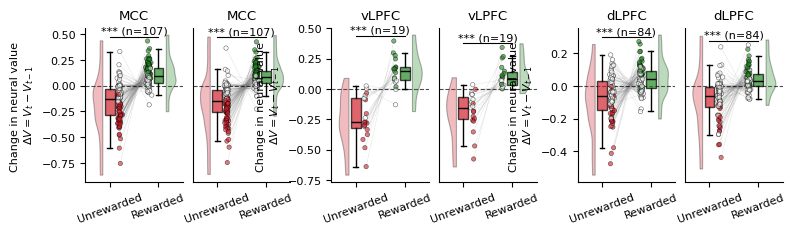

In [19]:
# Plot session-wise results
fig, axs = plot_session_wise(results_df_mean, monkeys='both')
#plt.tight_layout()
# Add title
#fig.suptitle('Neural value across target - session-wise results', fontsize=14, y=1.02)
# Save the figure
fig.savefig(os.path.join(PATH, 'notebooks', 'population_decoding', 'figs', 'rl_vs_forage', 'session_wise_both_monkeys.svg'), 
            bbox_inches='tight', dpi=300, transparent=True)

## Print stats (all sessions)


ka - MCC:
  Foraging: 28 sessions (48.3%)
  RL simple: 4 sessions (6.9%)
  none: 26 sessions (44.8%)

ka - dLPFC:
  Foraging: 7 sessions (15.2%)
  RL simple: 5 sessions (10.9%)
  none: 34 sessions (73.9%)

ka - vLPFC:
  Foraging: 6 sessions (50.0%)
  RL simple: 3 sessions (25.0%)
  none: 3 sessions (25.0%)

po - MCC:
  Foraging: 14 sessions (28.6%)
  RL simple: 8 sessions (16.3%)
  none: 27 sessions (55.1%)

po - dLPFC:
  Foraging: 4 sessions (10.5%)
  RL simple: 7 sessions (18.4%)
  none: 27 sessions (71.1%)

po - vLPFC:
  Foraging: 3 sessions (42.9%)
  RL simple: 1 sessions (14.3%)
  none: 3 sessions (42.9%)



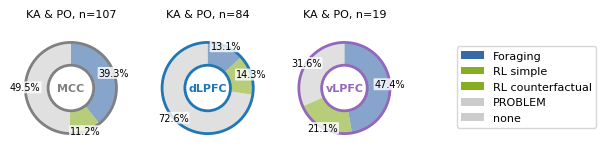

In [11]:
# Extract hypothesis info
stats_df = extract_hypothesis(res)

fig, axs = print_stats(stats_df)
# save figure as svg
fig.savefig(os.path.join(PATH, 'notebooks', 'population_decoding', 'figs', 'rl_vs_forage', 'RL_forage_pies_both.svg'), format='svg', bbox_inches='tight', dpi=300, transparent=True)